In [17]:
using LinearAlgebra
using Plots
using LaTeXStrings
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

## LDOS and DOS with Auxiliary Degrees of Freedom

`get_ldos_spatial`, `get_ldos_online`, and `get_dos_stochastic` accept the same
projection keywords as `get_bands`:

| Keyword | `proj_*=nothing` | `proj_*=k` |
|---------|-----------------|------------|
| `spin_proj=true` | sum ↑+↓ | select sector k (1=↑, 2=↓) |
| `nambu_proj=true` (to be added later)| sum particle+hole | select sector k (1=p, 2=h) | 
| `sublat_proj=true` | sum all sublattices | select sublattice k |

All auxiliary DOFs present in H must be projected when any `*_proj=true` flag is set.


H0: TBHamiltonian | L=20, N=1048576, scale=3.0, maxlinkdim=3 | geometry: 1048576 sites, 1D | no Tn cache


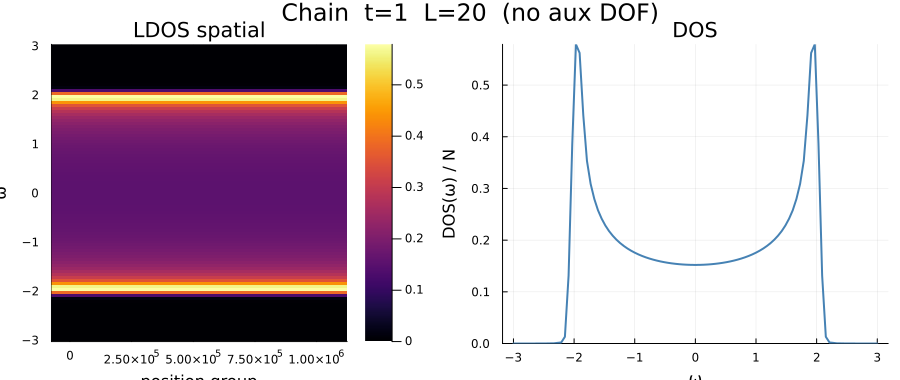

In [19]:
# ─── Case 0: featureless 1D chain (no auxiliary DOF) ─────────────────────
L0  = 20 # chain beyond 1 million sites to show how quick this works with the online mpo method for a featureless system (no aux DOF)
H0  = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L0, scale=3.0)

println("H0: ", H0)

ωl0 = range(-3.0, 3.0; length=100)
Nc0 = 100
nx0 = 8 # number of spatial points to sample for the LDOS (evenly spaced along the chain)
nxs = 1 # number of additional points to average over (for demonstration purposes, useful for large systems)

ldos0 = TensorBinding.get_ldos_spatial(H0, Nc0, ωl0;
    num_x=nx0,  mode=:mpo, maxdim=50)

# normalize=true → divide by H.N → per-site DOS, independent of L
dos0  = TensorBinding.get_dos_stochastic(H0, Nc0, ωl0;
    N_sample=30, seed=42, maxdim=50, normalize=true)

p1 = heatmap(range(1, H0.N, nx0), collect(ωl0), ldos0;
    title="LDOS spatial", xlabel="position group", ylabel="ω",
    color=:inferno)
p2 = plot(ωl0, dos0;
    title="DOS", xlabel="ω", ylabel="DOS(ω) / N",
    lw=2, color=:steelblue, label="", ylims=(0, Inf))
plot(p1, p2; layout=(1,2), size=(900,380),
    plot_title="Chain  t=1  L=$L0  (no aux DOF)")


KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.1856,  E_max = 2.1907
  center = 0.0025,  scale = 2.407


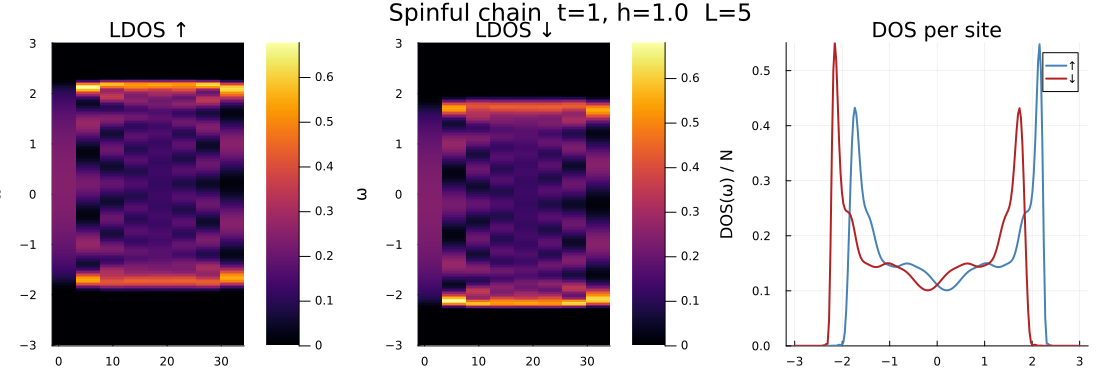

In [20]:
# ─── Case 1: spin-1/2 chain with Zeeman field ─────────────────────────────
L1  = 5
H1  = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L1, scale=3.0)
TensorBinding.add_spin!(H1)          # prepends dim-2 spin aux site → H1.spin_s set
TensorBinding.add_zeeman!(H1, 0.4)  # uniform h=0.4 splits ↑/↓ bands by ±0.2

ωl1  = range(-3.0, 3.0; length=200)
Nc1  = 60
nx1  = 8

ldos1_up = TensorBinding.get_ldos_spatial(H1, Nc1, ωl1;
    spin_proj=true, proj_s=1, num_x=nx1, mode=:mpo, maxdim=50)
ldos1_dn = TensorBinding.get_ldos_spatial(H1, Nc1, ωl1;
    spin_proj=true, proj_s=2, num_x=nx1, mode=:mpo, maxdim=50)

dos1_up  = TensorBinding.get_dos_stochastic(H1, Nc1, ωl1;
    spin_proj=true, proj_s=1, N_sample=40, seed=42, maxdim=50, normalize=true)
dos1_dn  = TensorBinding.get_dos_stochastic(H1, Nc1, ωl1;
    spin_proj=true, proj_s=2, N_sample=40, seed=42, maxdim=50, normalize=true)

pa1 = heatmap(range(1, H1.N, nx1), collect(ωl1), ldos1_up;
    title="LDOS ↑", xlabel="x", ylabel="ω", color=:inferno)
pb1 = heatmap(range(1, H1.N, nx1), collect(ωl1), ldos1_dn;
    title="LDOS ↓", xlabel="x", ylabel="ω", color=:inferno)
pc1 = plot(ωl1, dos1_up;
    title="DOS per site", xlabel="ω", ylabel="DOS(ω) / N",
    lw=2, color=:steelblue, label="↑", ylims=(0, Inf))
plot!(pc1, ωl1, dos1_dn;
    lw=2, color=:firebrick, label="↓")
plot(pa1, pb1, pc1; layout=(1,3), size=(1100,380),
    plot_title="Spinful chain  t=1, h=1.0  L=$L1")


KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -3.0253,  E_max = 3.0253
  center = -0.0,  scale = 3.3278


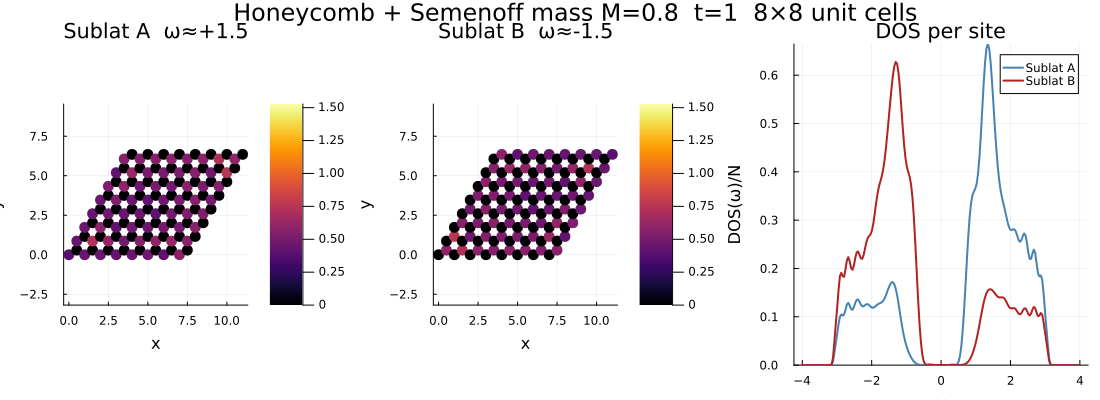

In [ ]:
# ─── Case 3: honeycomb + Semenoff mass (sublattice DOF — A / B) ──────────
Lx3 = 3; Ly3 = 3
H3  = TensorBinding.honeycomb_sublattice_hamiltonian(Lx3, Ly3, 1.0)

M = 0.8
TensorBinding.add_onsite!(H3, +M; sublat=1)   # +M on A
TensorBinding.add_onsite!(H3, -M; sublat=2)   # −M on B

ωl3  = range(-4.0, 4.0; length=200)
Nc3  = 80

# get_ldos_spatial auto-detects H.sublattice_s.
# Result shape: (Nω, 2*H3.N) — columns interleaved [A₀,B₀,A₁,B₁,…]
# proj_sl=1 → sublat-A columns filled, B columns zero; proj_sl=2 → vice versa.
ldos3_A = TensorBinding.get_ldos_spatial(H3, Nc3, ωl3;
    proj_sl=1, num_x=H3.N, mode=:mpo, maxdim=50)
ldos3_B = TensorBinding.get_ldos_spatial(H3, Nc3, ωl3;
    proj_sl=2, num_x=H3.N, mode=:mpo, maxdim=50)

dos3_A = TensorBinding.get_dos_stochastic(H3, Nc3, ωl3;
    sublat_proj=true, proj_sl=1, N_sample=40, seed=42, maxdim=50, normalize=true)

dos3_B = TensorBinding.get_dos_stochastic(H3, Nc3, ωl3;
    sublat_proj=true, proj_sl=2, N_sample=40, seed=42, maxdim=50, normalize=true)

clim_max = maximum(max.(ldos3_A, ldos3_B))
kw = (; geometry=:honeycomb, Lx=Lx3, Ly=Ly3,
        markersize=6, colormap=:inferno, clims=(0, clim_max))

# plot_ldos_2d takes the full-lattice matrix directly — no sublat argument
p_A = TensorBinding.plot_ldos_2d(ldos3_A, ωl3, 1.5;  title="Sublat A  ω≈+1.5", kw...)
p_B = TensorBinding.plot_ldos_2d(ldos3_B, ωl3, -1.5; title="Sublat B  ω≈-1.5", kw...)
p_dos = plot(ωl3, dos3_A   ;
    title="DOS per site", xlabel="ω", ylabel="DOS(ω)/N",
    lw=2, color=:steelblue, label="Sublat A", ylims=(0, Inf))
plot!(p_dos, ωl3, dos3_B;
    lw=2, color=:firebrick, label="Sublat B", ylims=(0, Inf))   
plot(p_A, p_B, p_dos; layout=(1,3), size=(1100,400),
    plot_title="Honeycomb + Semenoff mass M=$M  t=1  $(2^Lx3)×$(2^Ly3) unit cells")


In [ ]:
# ─── Case: kagome lattice (sublattice DOF — A / B / C) ───────────────────
# 3 sublattices: A/B/C  |  flat band at E=-2t, dispersive bands
Lx_kg = 3; Ly_kg = 3

# # Uniform kagome (backward compatible)
# H_kg = TensorBinding.kagome_hamiltonian(Lx_kg, Ly_kg, 1.0)

# # Break the flat band degeneracy with anisotropic hoppings: t_AB=1, t_AC=0.8, t_BC=0.6
H_kg = TensorBinding.kagome_hamiltonian(Lx_kg, Ly_kg; t_AB=1.0, t_AC=0.5, t_BC=0.3)

# adding a small sublattice potential:
MA = 0.4
MB = -0.2
MC = 0.3

TensorBinding.add_onsite!(H_kg, MA; sublat=1)
TensorBinding.add_onsite!(H_kg, MB; sublat=2)
TensorBinding.add_onsite!(H_kg, MC; sublat=3)

ωl_kg = range(-3, 3; length=100)
Nc_kg = 80

# get_ldos_spatial auto-detects H.sublattice_s.
# Result shape: (Nω, 3*H_kg.N) — columns interleaved [A₀,B₀,C₀,A₁,B₁,C₁,…]
# proj_sl=1 → sublat-A columns filled, B/C columns zero
# proj_sl=2 → sublat-B columns filled, A/C columns zero
# proj_sl=3 → sublat-C columns filled, A/B columns zero
ldos_kg_A = TensorBinding.get_ldos_spatial(H_kg, Nc_kg, ωl_kg;
    proj_sl=1, num_x=H_kg.N, mode=:mpo, maxdim=50)

ldos_kg_B = TensorBinding.get_ldos_spatial(H_kg, Nc_kg, ωl_kg;
    proj_sl=2, num_x=H_kg.N, mode=:mpo, maxdim=50)

ldos_kg_C = TensorBinding.get_ldos_spatial(H_kg, Nc_kg, ωl_kg;
    proj_sl=3, num_x=H_kg.N, mode=:mpo, maxdim=50)

dos_kg_A = TensorBinding.get_dos_stochastic(H_kg, Nc_kg, ωl_kg;
    sublat_proj=true, proj_sl=1, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_kg_B = TensorBinding.get_dos_stochastic(H_kg, Nc_kg, ωl_kg;
    sublat_proj=true, proj_sl=2, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_kg_C = TensorBinding.get_dos_stochastic(H_kg, Nc_kg, ωl_kg;
    sublat_proj=true, proj_sl=3, N_sample=40, seed=42, maxdim=50, normalize=true);


KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.908,  E_max = 2.6324
  center = 0.3622,  scale = 2.4972


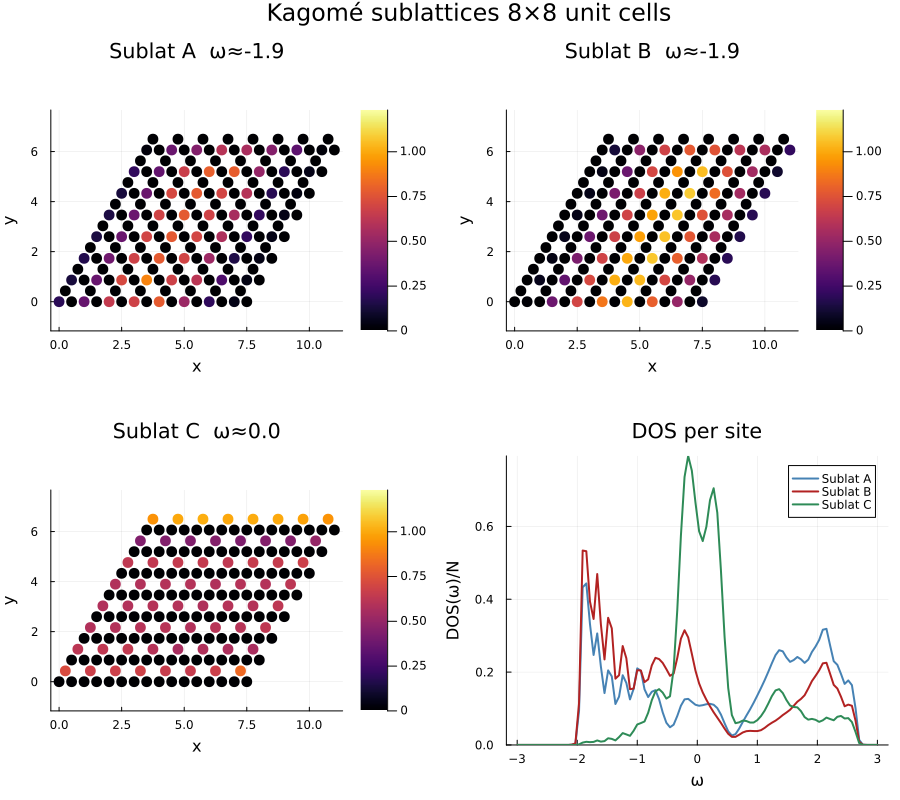

In [ ]:
clim_kg = maximum(max.(ldos_kg_A, ldos_kg_B, ldos_kg_C))

kw_kg = (; geometry=:kagome, Lx=Lx_kg, Ly=Ly_kg,
    markersize=6, colormap=:inferno, clims=(0, clim_kg))

en1 = -1.9
en2 = -1.9
en3 = 0.0

p_kg_A = TensorBinding.plot_ldos_2d(ldos_kg_A, ωl_kg, en1;
    title="Sublat A  ω≈$(en1)", kw_kg...)

p_kg_B = TensorBinding.plot_ldos_2d(ldos_kg_B, ωl_kg, en2;
    title="Sublat B  ω≈$(en2)", kw_kg...)

p_kg_C = TensorBinding.plot_ldos_2d(ldos_kg_C, ωl_kg, en3;
    title="Sublat C  ω≈$(en3)", kw_kg...)

p_dos_kg = plot(ωl_kg, dos_kg_A;
    title="DOS per site", xlabel="ω", ylabel="DOS(ω)/N",
    lw=2, color=:steelblue, label="Sublat A", ylims=(0, Inf))

plot!(p_dos_kg, ωl_kg, dos_kg_B;
    lw=2, color=:firebrick, label="Sublat B", ylims=(0, Inf))

plot!(p_dos_kg, ωl_kg, dos_kg_C;
    lw=2, color=:seagreen, label="Sublat C", ylims=(0, Inf))

plot(p_kg_A, p_kg_B, p_kg_C, p_dos_kg;
    layout=(2,2), size=(900,800),
    plot_title="Kagomé sublattices $(2^Lx_kg)×$(2^Ly_kg) unit cells")



In [ ]:
# ─── Lieb lattice (sublattice DOF — A / B / C) ───────────────────────────
# 3 sublattices: A (corner), B/C (edge centres)
# Flat band at E=0, dispersive bands around ±2√2
Lx_lb = 3; Ly_lb = 3
H_lb  = # Breathing Lieb: different bond strengths along x and y
H_lb = TensorBinding.lieb_hamiltonian(Lx_lb, Ly_lb; t_AB=1.0, t_AC=0.5)

M = 0.5

TensorBinding.add_onsite!(H_lb, +M; sublat=1)   # A corner sites
TensorBinding.add_onsite!(H_lb,  0.001; sublat=2) # B edge centers
TensorBinding.add_onsite!(H_lb, -M; sublat=3)   # C edge centers


ωl_lb = range(-3, 3; length=100)
Nc_lb = 80

# get_ldos_spatial auto-detects H.sublattice_s.
# Result shape: (Nω, 3*H_lb.N) — columns interleaved [A₀,B₀,C₀,A₁,B₁,C₁,…]
# proj_sl=1 → sublat-A columns filled, B/C columns zero
# proj_sl=2 → sublat-B columns filled, A/C columns zero
# proj_sl=3 → sublat-C columns filled, A/B columns zero
ldos_lb_A = TensorBinding.get_ldos_spatial(H_lb, Nc_lb, ωl_lb;
    proj_sl=1, num_x=H_lb.N, mode=:mpo, maxdim=50)

ldos_lb_B = TensorBinding.get_ldos_spatial(H_lb, Nc_lb, ωl_lb;
    proj_sl=2, num_x=H_lb.N, mode=:mpo, maxdim=50)

ldos_lb_C = TensorBinding.get_ldos_spatial(H_lb, Nc_lb, ωl_lb;
    proj_sl=3, num_x=H_lb.N, mode=:mpo, maxdim=50)

dos_lb_A = TensorBinding.get_dos_stochastic(H_lb, Nc_lb, ωl_lb;
    sublat_proj=true, proj_sl=1, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_lb_B = TensorBinding.get_dos_stochastic(H_lb, Nc_lb, ωl_lb;
    sublat_proj=true, proj_sl=2, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_lb_C = TensorBinding.get_dos_stochastic(H_lb, Nc_lb, ωl_lb;
    sublat_proj=true, proj_sl=3, N_sample=40, seed=42, maxdim=50, normalize=true);



KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.0319,  E_max = 2.4248
  center = 0.1964,  scale = 2.4512


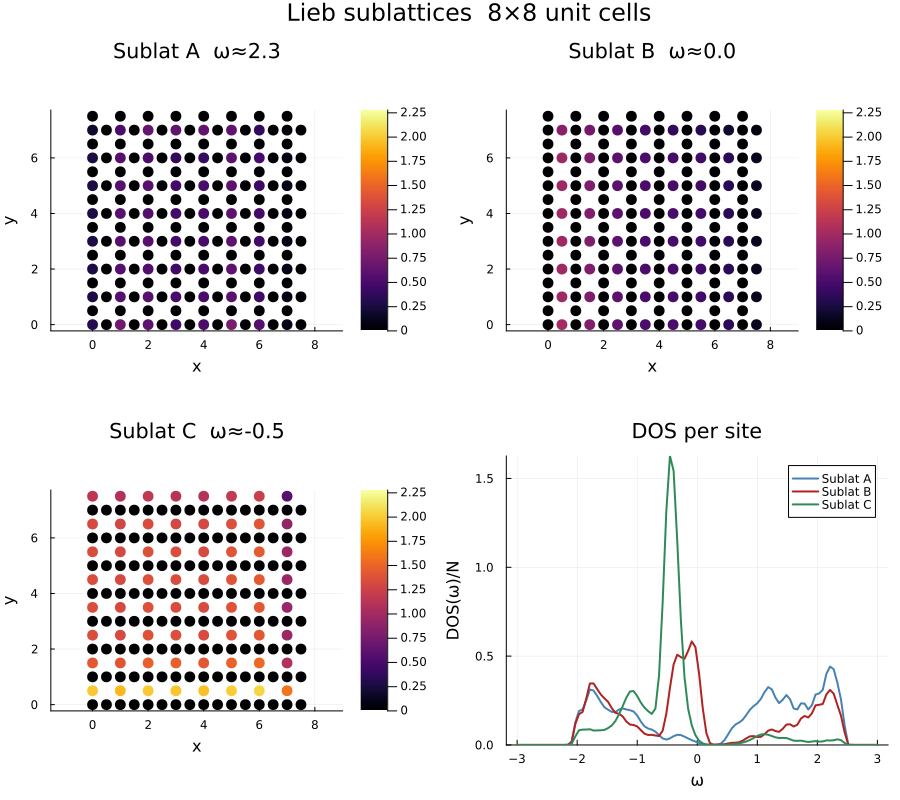

In [ ]:
clim_lb = maximum(max.(ldos_lb_A, ldos_lb_B, ldos_lb_C))

kw_lb = (; geometry=:lieb, Lx=Lx_lb, Ly=Ly_lb,
    markersize=6, colormap=:inferno, clims=(0, clim_lb))

en1 = 2.3
en2 = 0.0
en3 = -0.5

p_lb_A = TensorBinding.plot_ldos_2d(ldos_lb_A, ωl_lb, en1;
    title="Sublat A  ω≈$(en1)", kw_lb...)

p_lb_B = TensorBinding.plot_ldos_2d(ldos_lb_B, ωl_lb, en2;
    title="Sublat B  ω≈$(en2)", kw_lb...)

p_lb_C = TensorBinding.plot_ldos_2d(ldos_lb_C, ωl_lb, en3;
    title="Sublat C  ω≈$(en3)", kw_lb...)

p_dos_lb = plot(ωl_lb, dos_lb_A;
    title="DOS per site", xlabel="ω", ylabel="DOS(ω)/N",
    lw=2, color=:steelblue, label="Sublat A", ylims=(0, Inf))

plot!(p_dos_lb, ωl_lb, dos_lb_B;
    lw=2, color=:firebrick, label="Sublat B", ylims=(0, Inf))

plot!(p_dos_lb, ωl_lb, dos_lb_C;
    lw=2, color=:seagreen, label="Sublat C", ylims=(0, Inf))

plot(p_lb_A, p_lb_B, p_lb_C, p_dos_lb;
    layout=(2,2), size=(900,800),
    plot_title="Lieb sublattices  $(2^Lx_lb)×$(2^Ly_lb) unit cells")

In [ ]:
# ─── Dice (T3) lattice (sublattice DOF — A / B / C) ──────────────────────
# 3 sublattices: A (hub), B/C (rim)
# Flat band at E=0, dispersive bands around ±3t
Lx_dc = 3; Ly_dc = 3

H_dc = TensorBinding.dice_hamiltonian(Lx_dc, Ly_dc; t_AB=-0.7, t_AC=1.4)

M = 1.5

TensorBinding.add_onsite!(H_dc, +M; sublat=1)   # A 
TensorBinding.add_onsite!(H_dc,  -M; sublat=2) # B 
TensorBinding.add_onsite!(H_dc, -0.5*M; sublat=3)   # C


ωl_dc = range(-4.5, 4.5; length=100)
Nc_dc = 80

# get_ldos_spatial auto-detects H.sublattice_s.
# Result shape: (Nω, 3*H_dc.N) — columns interleaved [A₀,B₀,C₀,A₁,B₁,C₁,…]
# proj_sl=1 → sublat-A columns filled, B/C columns zero
# proj_sl=2 → sublat-B columns filled, A/C columns zero
# proj_sl=3 → sublat-C columns filled, A/B columns zero
ldos_dc_A = TensorBinding.get_ldos_spatial(H_dc, Nc_dc, ωl_dc;
    proj_sl=1, num_x=H_dc.N, mode=:mpo, maxdim=50)

ldos_dc_B = TensorBinding.get_ldos_spatial(H_dc, Nc_dc, ωl_dc;
    proj_sl=2, num_x=H_dc.N, mode=:mpo, maxdim=50)

ldos_dc_C = TensorBinding.get_ldos_spatial(H_dc, Nc_dc, ωl_dc;
    proj_sl=3, num_x=H_dc.N, mode=:mpo, maxdim=50)

dos_dc_A = TensorBinding.get_dos_stochastic(H_dc, Nc_dc, ωl_dc;
    sublat_proj=true, proj_sl=1, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_dc_B = TensorBinding.get_dos_stochastic(H_dc, Nc_dc, ωl_dc;
    sublat_proj=true, proj_sl=2, N_sample=40, seed=42, maxdim=50, normalize=true);

dos_dc_C = TensorBinding.get_dos_stochastic(H_dc, Nc_dc, ωl_dc;
    sublat_proj=true, proj_sl=3, N_sample=40, seed=42, maxdim=50, normalize=true);



KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -4.4318,  E_max = 5.0183
  center = 0.2933,  scale = 5.1975


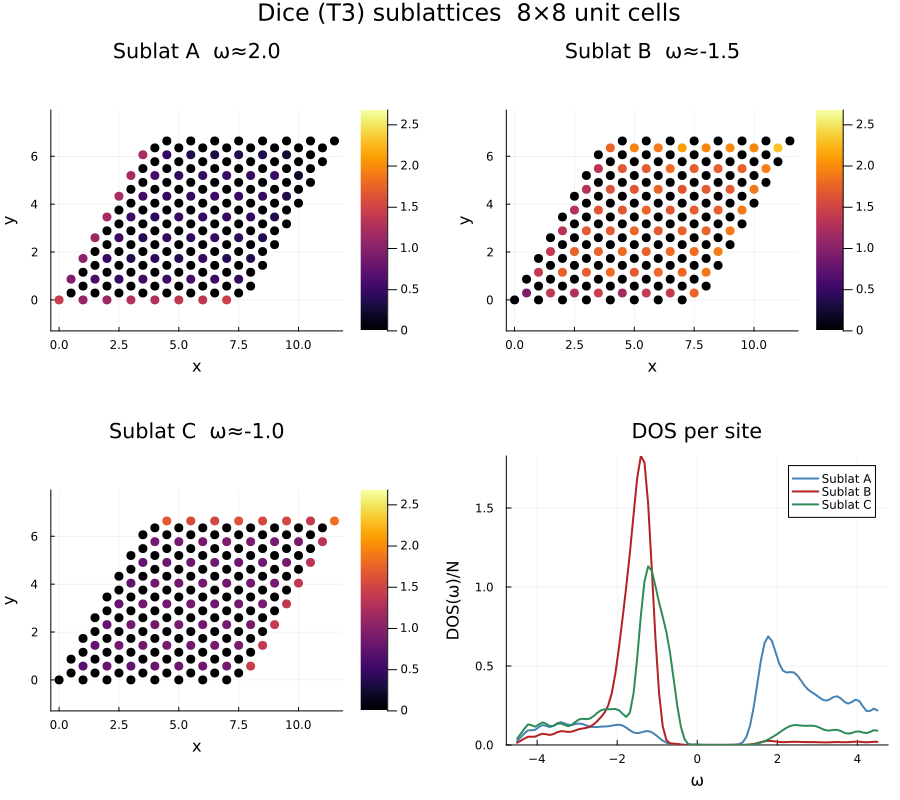

In [ ]:

clim_dc = maximum(max.(ldos_dc_A, ldos_dc_B, ldos_dc_C))


en1 = 2.0
en2 = -1.5
en3 = -1.0


kw_dc = (; geometry=:dice, Lx=Lx_dc, Ly=Ly_dc,
    markersize=5, colormap=:inferno, clims=(0, clim_dc))

p_dc_A = TensorBinding.plot_ldos_2d(ldos_dc_A, ωl_dc, en1;
    title="Sublat A  ω≈$(en1)", kw_dc...)

p_dc_B = TensorBinding.plot_ldos_2d(ldos_dc_B, ωl_dc, en2;
    title="Sublat B  ω≈$(en2)", kw_dc...)

p_dc_C = TensorBinding.plot_ldos_2d(ldos_dc_C, ωl_dc, en3;
    title="Sublat C  ω≈$(en3)", kw_dc...)

p_dos_dc = plot(ωl_dc, dos_dc_A;
    title="DOS per site", xlabel="ω", ylabel="DOS(ω)/N",
    lw=2, color=:steelblue, label="Sublat A", ylims=(0, Inf))

plot!(p_dos_dc, ωl_dc, dos_dc_B;
    lw=2, color=:firebrick, label="Sublat B", ylims=(0, Inf))

plot!(p_dos_dc, ωl_dc, dos_dc_C;
    lw=2, color=:seagreen, label="Sublat C", ylims=(0, Inf))

plot(p_dc_A, p_dc_B, p_dc_C, p_dos_dc;
    layout=(2,2), size=(900,800),
    plot_title="Dice (T3) sublattices  $(2^Lx_dc)×$(2^Ly_dc) unit cells")